# Resampling strategies for imbalanced datasets

https://www.kaggle.com/rafjaa/resampling-strategies-for-imbalanced-datasets
https://machinelearningmastery.com/undersampling-algorithms-for-imbalanced-classification/
https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/

## Note: We should apply any below undersampling or Oversampling tech only to Training data, we should not change Test data. It should remain same as real life unbalanced data to test this

### So 1st split the data by train_test_split() and then apply below method to train dataset (xtrain and ytrain)
- X_train_smt, y_train_smt = smt.fit_resample(X_train_new,y_train_new)

**Data**
    
    Imbalanced datasets
    The metric trap
    Confusion matrix

**Resampling**
   
    1. Random Under-sampling
    2. Random Over-sampling
    
**Python imbalanced-learn module BY library - imblearn **

    3. Random Under-sampling 
    4. Random Over-sampling with imbalanced-learn
    
**Undersampling - Methods that select DATA to delete from the majority class.**

    5. Under-sampling: 1) Tomek links  2) Edited Nearest Neighbors Rule 
    
**Undersampling - Cluster Centroids**

    6. Under-sampling: Cluster Centroids - Undersample by generating centroids based on clustering methods.

**Oversampling -SMOTE**

    7. Over-sampling: SMOTE
    8. Over-sampling followed by Under-sampling -- SMOTE + Tomek links
    
**Other few Undersampling**

    9. Near Miss Undersampling: 
    10. Condensed Nearest Neighbor Rule Undersampling
    11. Edited Nearest Neighbors Rule for Undersampling
    


**Different Unbalanced dataset**

- Insurance claims can be considered unusual cases when considering all clients. 

- Detection of financial fraud and attacks on computer networks.

- NPA Detection

# Porto Seguro’s Safe Driver Prediction

- Nothing ruins the thrill of buying a brand new car more quickly than seeing your new insurance bill. The sting’s even more painful when you know you’re a good driver. It doesn’t seem fair that you have to pay so much if you’ve been cautious on the road for years.

- Porto Seguro, one of Brazil’s largest auto and homeowner insurance companies, completely agrees. Inaccuracies in car insurance company’s claim predictions raise the cost of insurance for good drivers and reduce the price for bad ones.

- In this competition, you’re challenged to build a model that predicts the probability that a driver will initiate an **auto insurance claim in the next year**. While Porto Seguro has used machine learning for the past 20 years, they’re looking to Kaggle’s machine learning community to explore new, more powerful methods. A more accurate prediction will allow them to further tailor their prices, and hopefully make auto insurance coverage more accessible to more drivers.

## Scoring Metric

- Submissions are evaluated using the **Normalized Gini Coefficient**.

- During scoring, observations are sorted from the largest to the smallest predictions. Predictions are only used for ordering observations; therefore, the relative magnitude of the predictions are not used during scoring. The scoring algorithm then compares the cumulative proportion of positive class observations to a theoretical uniform proportion.

- The Gini Coefficient ranges from approximately 0 for random guessing, to approximately 0.5 for a perfect score. The theoretical maximum for the discrete calculation is (1 - frac_pos) / 2.

- The Normalized Gini Coefficient adjusts the score by the theoretical maximum so that the maximum score is 1.

- The code to calculate Normalized Gini Coefficient in a number of different languages can be found in this forum thread.
https://www.kaggle.com/c/porto-seguro-safe-driver-prediction/overview/evaluation


## Submission File

- For each id in the test set, you must predict **a probability** of an insurance claim in the target column. The file should contain a header and have the following format:


    id,target
    0,0.1
    1,0.9
    2,1.0
    
 ##  Understanding:
 
 - Few bad driver will claim frequently by using auto claim option, so company wants to track those kind of people who use auto insurance claim in the next year and those categorized as A more probability and business will plan to charge more for that customer insurence policy renewal

## Data Description:


- In this competition, you will predict the probability that an auto insurance policy holder files a claim.

- In the train and test data, features that belong to similar groupings are tagged as such in the feature names  - (e.g., ind, reg, car, calc). 

- In addition, feature names include the postfix **bin to indicate binary features** and **cat to indicate categorical features**. Features **without these designations are either continuous or ordinal**. Values of **-1 indicate that the feature was missing** from the observation. The target columns signifies whether or not a claim was filed for that policy holder.

### File descriptions

- train.csv contains the training data, where each row corresponds to a policy holder, and the target columns signifies that a claim was filed.
- test.csv contains the test data.
- sample_submission.csv is submission file showing the correct format.

In [4]:
import numpy as np
import pandas as pd

df_train = pd.read_csv(r'../Dataset/Porto_Seg_Insurence/train.csv')
df_train.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


0    573518
1     21694
Name: target, dtype: int64

Class 0 - Not Autoclaimed: 573518
Class 1 - Autoclaimed: 21694

Proportion: 26.44 : 1


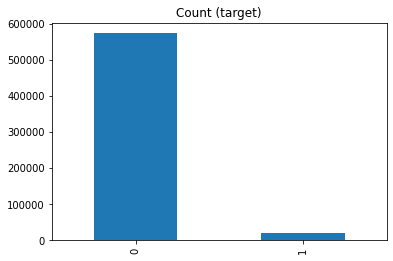

In [10]:

#In dataset target is OP column
target_count = df_train.target.value_counts()
print(target_count)
print('\nClass 0 - Not Autoclaimed:', target_count[0])
print('Class 1 - Autoclaimed:', target_count[1])
print('\nProportion:', round(target_count[0] / target_count[1], 2), ': 1')

target_count.plot(kind='bar', title='Count (target)');

> This tells 26.44 time not claimed

##### The metric trap

- One of the major issues  when dealing with unbalanced datasets relates to the metrics used to evaluate their model. 

- Using simpler metrics like accuracy_score can be misleading. In a dataset with highly unbalanced classes, if the classifier always "predicts" the most common class without performing any analysis of the features, it will still have a high accuracy rate, obviously illusory.


- Let's do this experiment, using simple cross-validation and no feature engineering:

In [14]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Remove 'id' and 'target' columns
labels = df_train.columns[2:]

X = df_train[labels]
y = df_train['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

model = XGBClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

C:\Users\prabh\Anaconda3\lib\site-packages\xgboost\sklearn.py:1146: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[12:08:29] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Accuracy: 96.35%


- Now let's run the same code, but using only one feature (which should drastically reduce the accuracy of the classifier):

In [15]:
model = XGBClassifier()
model.fit(X_train[['ps_calc_01']], y_train)
y_pred = model.predict(X_test[['ps_calc_01']])

accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy: %.2f%%" % (accuracy * 100.0))

C:\Users\prabh\Anaconda3\lib\site-packages\xgboost\sklearn.py:1146: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[12:12:56] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.4.0/src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.

Accuracy: 96.36%


> But here accuracy didnt reduce, so imbalanced data we should handle 

>  So matric used for imbalanced data is also very important

>   In this competition, the evaluation metric is the Normalized Gini Coefficient, a more robust metric for imbalanced datasets, that ranges from approximately 0 for random guessing, to approximately 0.5 for a perfect score.

### Confusion matrix
An interesting way to evaluate the results is by means of a confusion matrix, which shows the correct and incorrect predictions for each class. In the first row, the first column indicates how many classes 0 were predicted correctly, and the second column, how many classes 0 were predicted as 1. In the second row, we note that all class 1 entries were erroneously predicted as class 0.

Therefore, the higher the diagonal values of the confusion matrix the better, indicating many correct predictions.

Confusion matrix:
 [[114709      0]
 [  4334      0]]


C:\Users\prabh\Anaconda3\lib\site-packages\ipykernel_launcher.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  if sys.path[0] == '':
C:\Users\prabh\Anaconda3\lib\site-packages\ipykernel_launcher.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  del sys.path[0]


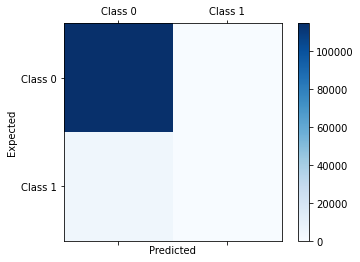

In [16]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt

conf_mat = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', conf_mat)

labels = ['Class 0', 'Class 1']
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(conf_mat, cmap=plt.cm.Blues)

fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.show()

> Here non of the Claim correctly predicted as claimed

## Resampling

- A widely adopted technique for dealing with highly unbalanced datasets is called resampling. 
- It consists of removing samples from the majority class (under-sampling) and / or adding more examples from the minority class (over-sampling).

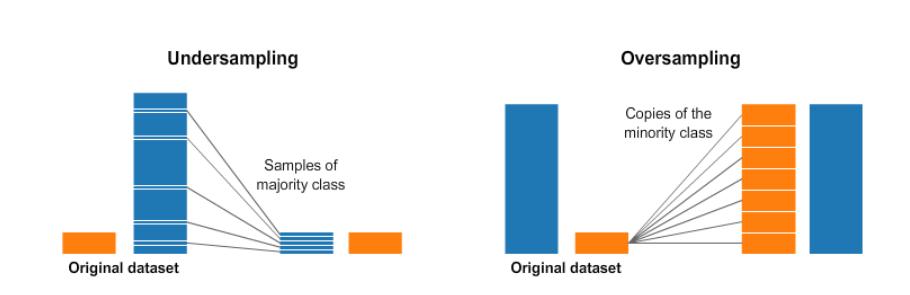


- Instead of balancing, these techniques also have their weaknesses..
- The simplest implementation of **over-sampling** is to duplicate random records from the minority class, which can cause **overfitting**. 
- In **under-sampling**, the simplest technique involves removing random records from the majority class, which can **cause loss of information**.


In [19]:
# Class count
count_class_0, count_class_1 = df_train.target.value_counts()
print("Class 0 Count: ", count_class_0)
print("Class 1 Count: ", count_class_1)

# Separate whole data by class
df_class_0 = df_train[df_train['target'] == 0]
df_class_1 = df_train[df_train['target'] == 1]

Class 0 Count:  573518
Class 1 Count:  21694


# 1. Random under-sampling

Random under-sampling:
0    21694
1    21694
Name: target, dtype: int64


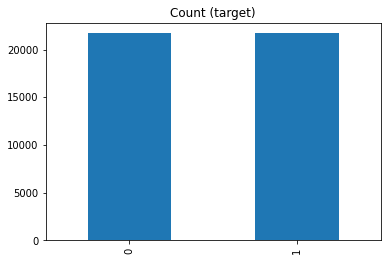

In [20]:
## Here we sample only 21694 sample records from majority class =1
df_class_0_under = df_class_0.sample(count_class_1)
df_test_under = pd.concat([df_class_0_under, df_class_1], axis=0)

print('Random under-sampling:')
print(df_test_under.target.value_counts())

df_test_under.target.value_counts().plot(kind='bar', title='Count (target)');

# 2. Random Over-sampling

Random over-sampling:
0    573518
1    573518
Name: target, dtype: int64


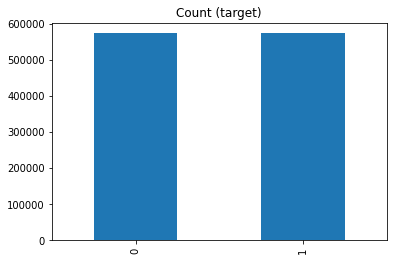

In [22]:
## Here we repeat 21694 minority (class=1) data to become count =  573518
## Here we sample 573518 (class=0) record from from minority class =1


df_class_1_over = df_class_1.sample(count_class_0, replace=True)
df_test_over = pd.concat([df_class_0, df_class_1_over], axis=0)

print('Random over-sampling:')
print(df_test_over.target.value_counts())

df_test_over.target.value_counts().plot(kind='bar', title='Count (target)');

## Python imbalanced-learn module

- Other than these 2 we have different type of other resampling Techniques


- **Cluster Sampling** - For example, we can cluster the records of the majority class, and do the under-sampling by removing records from each cluster, thus seeking to preserve information. 

- **SMOTE** - In over-sampling, instead of creating exact copies of the minority class records, we can introduce small variations into those copies, creating more diverse synthetic samples.

 - Let's apply some of these resampling techniques, using the Python library imbalanced-learn. It is compatible with scikit-learn and is part of scikit-learn-contrib projects.

## COOKUP DATA FOR TEST using the **make_classification**

In [25]:
import imblearn

>  For ease of visualization, let's create a small unbalanced sample dataset using the **make_classification** method:

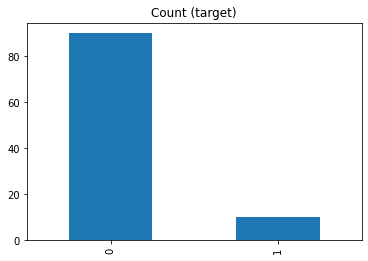

In [27]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_classes=2, class_sep=1.5, weights=[0.9, 0.1],
    n_informative=3, n_redundant=1, flip_y=0,
    n_features=20, n_clusters_per_class=1,
    n_samples=100, random_state=10
)

df = pd.DataFrame(X)
df['target'] = y
df.target.value_counts().plot(kind='bar', title='Count (target)');

In [31]:
print(X)  # Array of ip feature , more than 1 ip
print(y)

[[ 0.32741905 -0.12393639  0.37770717 ...  1.5537068   1.49753796
  -1.47648462]
 [-0.8439811  -0.01869095 -0.84101809 ...  1.22578623 -0.84287957
   1.30325836]
 [-0.20464188  0.4721547  -0.14061575 ...  1.38647421 -0.07333455
   0.58685924]
 ...
 [-0.01149679 -0.67015443 -0.50984477 ...  1.09037772 -1.38810392
  -0.30467818]
 [ 1.10759027  1.03486329  0.46197961 ...  1.33694637 -0.11743108
  -0.32402202]
 [-0.50311809 -0.96025532 -0.35567573 ...  2.01443339 -2.04940322
  -1.3426984 ]]
[0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


> We will also create a 2-dimensional plot function, plot_2d_space, to see the data distribution:

- X dataset 1st value as X-axis and 2nd value  as Y-axis and output as different shape

In [50]:
def plot_2d_space(X, y, label='Classes'):   
    colors = ['#1F77B4', '#FF7F0E']
    markers = ['o', 's']
    
    for l, c, m in zip(np.unique(y), colors, markers):
        plt.scatter(
            X[y==l, 0],  ## Here Scattter plot X value  --> X[y==0 , 0 ]  -->  it gives all records 1st value where output y=0
            X[y==l, 1], ## Here Scattter plot Y value  --> X[y==0 , 1 ] -->  it gives all records 2nd value where output y=0
            c=c, label=l, marker=m
        )
        
    plt.title(label)
    plt.legend(loc='upper right')
    plt.show()

    
        
    # HERE unique(y) will give 0,1 --> so HERE it for loop 2 time
        # 1st loop --> y value 0 --> Color '#1F77B4' --> shape oval 'o'
        # 2nd loop --> y value 1 --> Color '#FF7F0E' -->  shape diamond 's'
        
## In 1st iteration y=0:
        ## Here Scattter plot X value  --> X[y==0 , 0 ]  -->  it gives all records 1st value where output y=0
     ## Here Scattter plot Y value  --> X[y==0 , 1 ] -->  it gives all records 2nd value where output y=0
## In 2nd iteration y=1:
     ## Here Scattter plot X value  --> X[y==1 , 0 ]  -->  it gives all records 1st value where output y=1
     ## Here Scattter plot Y value  --> X[y==1 , 1 ] -->  it gives all records 2nd value where output y=1

> Because the dataset has many dimensions (features) and our graphs will be 2D, we will reduce the size of the dataset using Principal Component Analysis (PCA):

In [51]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X = pca.fit_transform(X)
print(X)

[[ 0.17745104 -1.83646187]
 [ 0.48334862  1.44135941]
 [-0.28203452 -1.19199943]
 [-0.63056485  1.41117742]
 [-2.54661668  0.07664698]
 [-2.52908894 -1.09239392]
 [-1.00025597  1.81970329]
 [-2.0229804  -2.72605005]
 [-2.91676826 -1.69253484]
 [-0.84399458  1.2748164 ]
 [-0.60981014 -0.80454728]
 [ 2.02999659  0.86791168]
 [ 0.09750093  0.15550449]
 [-0.10873544 -1.80630362]
 [-2.81687964 -0.00491207]
 [-0.68017965 -1.35671263]
 [-2.221968    0.96074098]
 [ 1.0138328   0.30191965]
 [ 1.03007313 -1.38625376]
 [ 2.60496404  0.29357503]
 [-0.45315449  0.44906397]
 [ 0.61547258  1.33795531]
 [ 0.86488853  1.58770896]
 [-1.32107149 -0.71351953]
 [-0.56817392 -0.3086317 ]
 [ 0.42775385  0.66260292]
 [ 1.88507801 -0.56332997]
 [ 0.06366303 -0.74718566]
 [ 1.06724797  0.06715039]
 [-0.28352454  0.34446522]
 [-1.30551164  0.22068739]
 [ 1.10941911  1.70492526]
 [ 0.85461308 -2.53975605]
 [-2.51252341  0.73488282]
 [-0.82575683 -0.05940094]
 [ 3.21272574  2.93867024]
 [ 0.64522832  0.17030986]
 

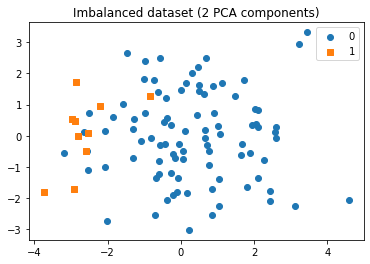

In [52]:
# hERE 
plot_2d_space(X, y, 'Imbalanced dataset (2 PCA components)')

> Here we can see more data on 0 and less on Class 1 in our cookup data

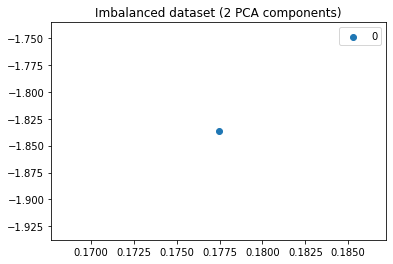

In [53]:
plot_2d_space(X[0], y[0], 'Imbalanced dataset (2 PCA components)')
# Here 1st row X = [ 0.17745104 -1.83646187]  --> Here  0.17745104 considered as X and  -1.83646187
# Here 1st row of Y = [0]

In [54]:
## X[y==0, 0],  X[y==0, 1]
## It gives  all records 1st value of X where output y=0 and   all records 2nd value of X where output y=0

## 3. Random Under-sampling  with imbalanced-learn Python

Counter({0: 90, 1: 10})
Counter({0: 10, 1: 10})


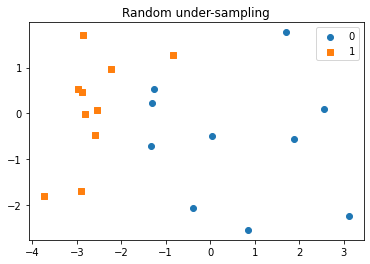

In [127]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

print(Counter(y))

rus = RandomUnderSampler()
X_rus, y_rus = rus.fit_resample(X, y)

## id_rus is the index no, which are removed from datset, but in new version this parameter not available, earlier we could have set return_indices=True to get this parameter
#rus = RandomUnderSampler(return_indices=True)
#X_rus, y_rus, id_rus = rus.fit_sample(X, y)
#print('Removed indexes:', id_rus)

print(Counter(y_rus)) 
plot_2d_space(X_rus, y_rus, 'Random under-sampling')


## 4. Random OverSampler 
- with imbalanced-learn Python

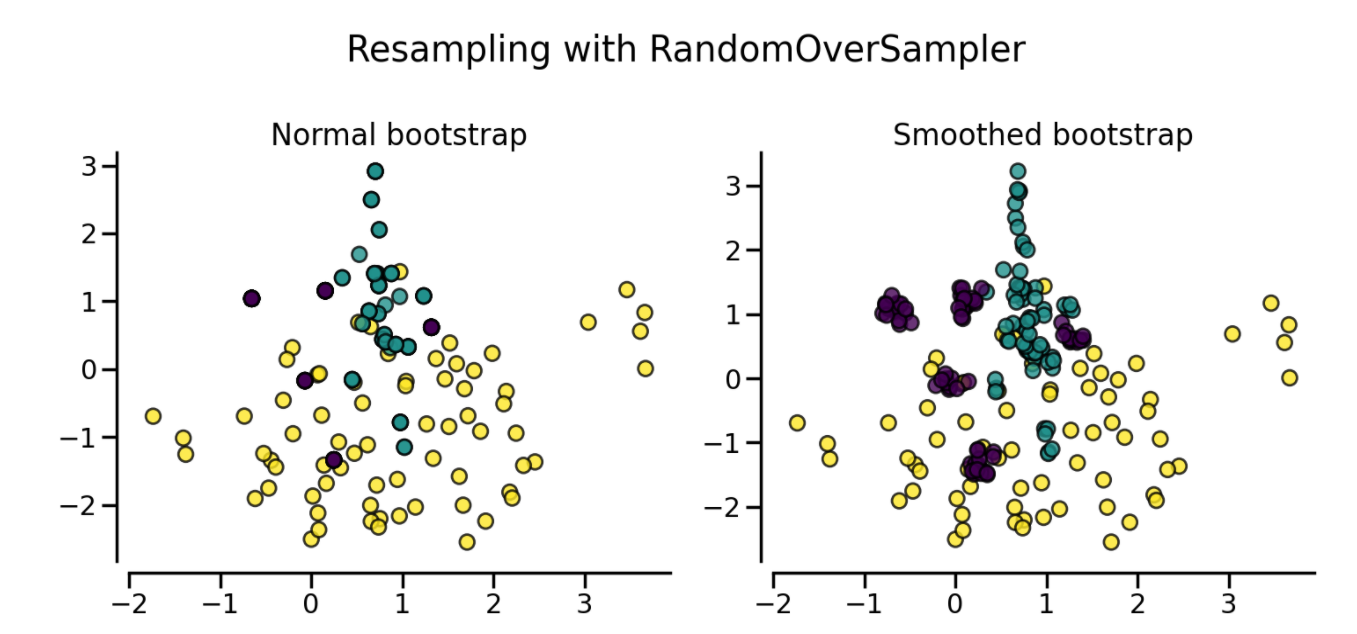

Counter({0: 90, 1: 10})
80 new random picked points
Counter({0: 90, 1: 90})


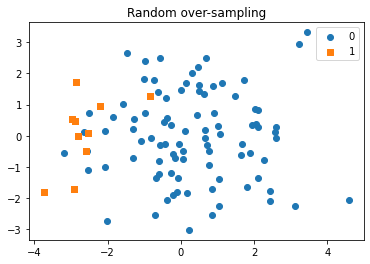

In [129]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

print(Counter(y))

ros = RandomOverSampler()
X_ros, y_ros = ros.fit_resample(X, y)

print(X_ros.shape[0] - X.shape[0], 'new random picked points')

print(Counter(y_ros))
plot_2d_space(X_ros, y_ros, 'Random over-sampling')

> Here minority count increased equal to majority count

## 5. Under-sampling: Tomek links  --> Methods that Select Minority/Majority to Delete

**Tomek links are used as an undersampling method and removes noisy and borderline majority class examples**

**This procedure can be used to find all of those examples in the majority class that are closest to the minority class, then removed.** So this normally used in binary class imbalance

- **Tomek links are pairs of very close instances, but of opposite classes**
- Removing the instances of the majority class of each pair increases the space between the two classes, facilitating the classification process.
- Here 1st very close instances of both class pairs are done, then that majority class instance are removed and kept only minority class instance --> **This way it reduces majority class count**



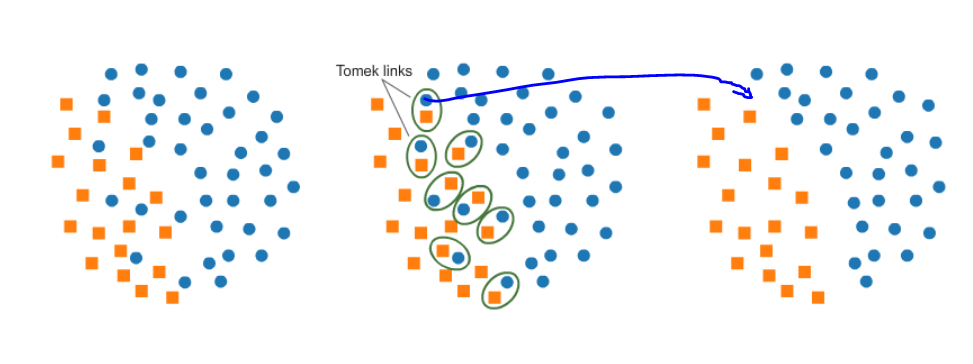


**class imblearn.under_sampling.TomekLinks(*, sampling_strategy='auto', n_jobs=None)**

> Here sampling_strategy can be anything below. str, list, callable

- When str, specify the class targeted by the resampling. Note the the number of samples will not be equal in each. Possible choices are:

            -        'majority': resample only the majority class;
            -        'not minority': resample all classes but the minority class;
            -        'not majority': resample all classes but the majority class;
            -        'all': resample all classes;
            -        'auto': equivalent to 'not minority'.

> When list, the list contains the classes targeted by the resampling.

> When callable, function taking y and returns a dict. The keys correspond to the targeted classes. The values correspond to the desired number of samples for each class.

> n_jobsint, default=None
        Number of CPU cores used during the cross-validation loop. None means 1

Counter({0: 90, 1: 10})
Original Plot


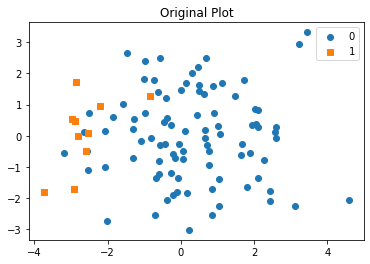

Counter({0: 86, 1: 10})
Resampled Plot: Few majority classes near the minority are removed


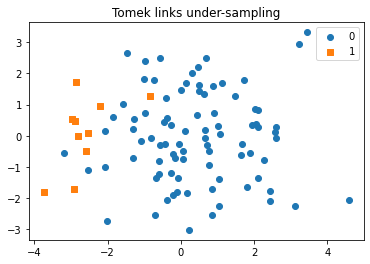

In [131]:
## In the code below, we'll use ratio='majority' to resample the majority class.

from imblearn.under_sampling import TomekLinks
from collections import Counter

print(Counter(y))

tl = TomekLinks(sampling_strategy='majority')
X_tl, y_tl = tl.fit_resample(X, y)

print("Original Plot")
plot_2d_space(X, y, 'Original Plot')

print(Counter(y_tl))
print("Resampled Plot: Few majority classes near the minority are removed")
plot_2d_space(X_tl, y_tl, 'Tomek links under-sampling')


## 6. Under-sampling: Cluster Centroids  
### Undersample by generating centroids based on clustering methods.

- This technique performs under-sampling by generating centroids based on clustering methods. 

- The data will be previously grouped by similarity, in order to preserve information.

- Here it samples same minority count records from majority class

- Here Method that under samples the majority class by replacing a cluster of majority samples by the cluster centroid of a KMeans algorithm. 

- This algorithm keeps N majority samples by fitting the KMeans algorithm with N cluster to the majority class and using the coordinates of the N cluster centroids as the new majority samples.

**class imblearn.under_sampling.ClusterCentroids(*, sampling_strategy='auto', random_state=None, estimator=None, voting='auto', n_jobs='deprecated')**

> Here sampling_strategy can be anything below. sampling_strategy: float, str, dict, callable, default=’auto’

            - When str, specify the class targeted by the resampling. 

            - The number of samples in the different classes will be equalized. Possible choices are:
                    -    'majority': resample only the majority class;
                    -    'not minority': resample all classes but the minority class;
                    -    'not majority': resample all classes but the majority class;
                    -    'all': resample all classes;
                    -    'auto': equivalent to 'not minority'.

            - When dict, the keys correspond to the targeted classes. The values correspond to the desired number of samples for each targeted class.

            - When callable, function taking y and returns a dict. The keys correspond to the targeted classes. The values correspond to the desired number of samples for each class.


> **random_state** int, RandomState instance, default=None
    
    - Control the randomization of the algorithm.
    - If int, random_state is the seed used by the random number generator;
    - If RandomState instance, random_state is the random number generator;
    - If None, the random number generator is the RandomState instance used by np.random.


> **estimator** estimator object, default=None

    - Pass a KMeans estimator. By default, it will be a default KMeans estimator.


> **voting{“hard”, “soft”, “auto”}, default=’auto’**

    - Voting strategy to generate the new samples:
    - If 'hard', the nearest-neighbors of the centroids found using the clustering algorithm will be used.
    - If 'soft', the centroids found by the clustering algorithm will be used.    - If 'auto', if the input is sparse, it will default on 'hard' otherwise, 'soft' will be used.

> **n_jobs**, default=None

    - Number of CPU cores used during the cross-validation loop. None means 1 unless in a joblib.parallel_backend context. -1 means using all processors. See Glossary for more details.

Counter({0: 90, 1: 10})
Original Plot


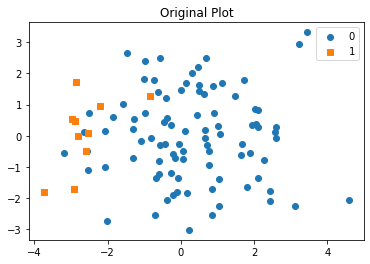

Counter({0: 10, 1: 10})
Resampled Plot: Cluster Centroids under-sampling


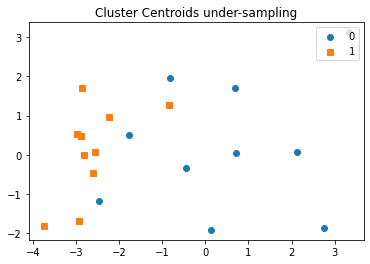

In [132]:
from imblearn.under_sampling import ClusterCentroids
from collections import Counter

print(Counter(y))

cc = ClusterCentroids()
X_cc, y_cc = cc.fit_resample(X, y)


print("Original Plot")
plot_2d_space(X, y, 'Original Plot')

print(Counter(y_cc))
print("Resampled Plot: Cluster Centroids under-sampling")
plot_2d_space(X_cc, y_cc, 'Cluster Centroids under-sampling')

> Here Majority classes count reduced, k mean clustering applied to Majority class and centroid is considered as the final one

## 7. Over-sampling: SMOTE

- SMOTE (Synthetic Minority Oversampling TEchnique) consists of synthesizing elements for the minority class, based on those that already exist. 
- It works randomly picingk a point from the minority class and computing the k-nearest neighbors for this point. The synthetic points are added between the chosen point and its neighbors.

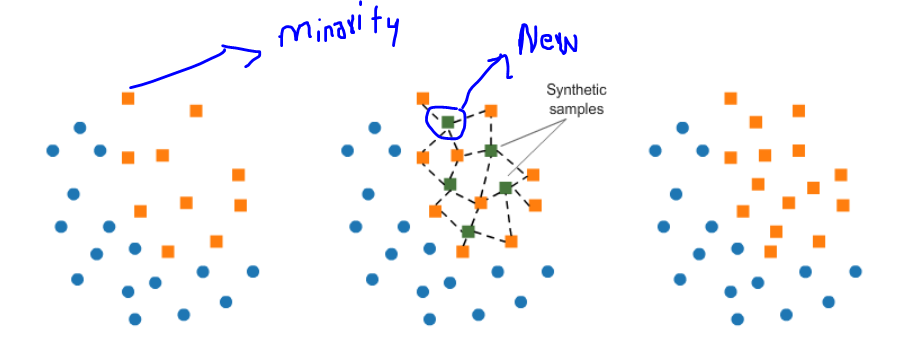

**class imblearn.over_sampling.SMOTE(*, sampling_strategy='auto', random_state=None, k_neighbors=5, n_jobs=None)**

> **sampling_strategy** - Sampling information to resample the data set.

        - When float, it corresponds to the desired ratio of the number of samples in the minority class over the number of samples in the majority class after resampling. Therefore, the ratio is expressed as \alpha_{os} = N_{rm} / N_{M} where N_{rm} is the number of samples in the minority class after resampling and N_{M} is the number of samples in the majority class.

        - When str, specify the class targeted by the resampling. The number of samples in the different classes will be equalized. Possible choices are:

                - 'minority': resample only the minority class;

                - 'not minority': resample all classes but the minority class;

                - 'not majority': resample all classes but the majority class;

                - 'all': resample all classes;

                - 'auto': equivalent to 'not majority'.

        - When dict, the keys correspond to the targeted classes. The values correspond to the desired number of samples for each targeted class.

        - When callable, function taking y and returns a dict. The keys correspond to the targeted classes. The values correspond to the desired number of samples for each class.

> **random_state** int, RandomState instance, default=None
        - Control the randomization of the algorithm.
        - If int, random_state is the seed used by the random number generator;
        - If RandomState instance, random_state is the random number generator;
        - If None, the random number generator is the RandomState instance used by np.random.

> **k_neighborsint** or object, default=5
        - If int, number of nearest neighbours to used to construct synthetic samples. If object, an estimator that inherits from KNeighborsMixin that will be used to find the k_neighbors.

> **n_jobsin**t, default=None
        -Number of CPU cores used during the cross-validation loop. None means 1 unless in a joblib.parallel_backend context. -1 means using all processors. See Glossary for more details.

**class imblearn.over_sampling.SMOTE(*, sampling_strategy='auto', random_state=None, k_neighbors=5, n_jobs=None)**

Counter({0: 90, 1: 10})
Original Plot


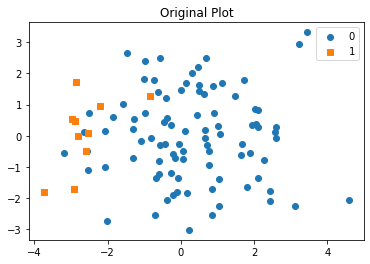

Counter({0: 90, 1: 90})
Resampled Plot: SMOTE over-sampling


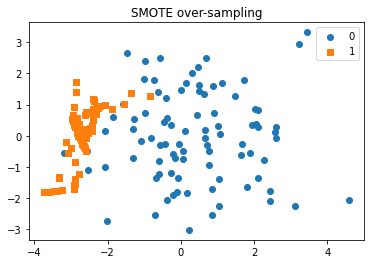

In [133]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(Counter(y))

smote = SMOTE(sampling_strategy = 'minority' )
X_sm, y_sm = smote.fit_resample(X, y)

print("Original Plot")
plot_2d_space(X, y, 'Original Plot')

print(Counter(y_sm))
print("Resampled Plot: SMOTE over-sampling")
plot_2d_space(X_sm, y_sm, 'SMOTE over-sampling')

> Here many minority points created

### Code snippest

https://towardsdatascience.com/the-right-way-of-using-smote-with-cross-validation-92a8d09d00c7

- Use SMOTE to avoid inaccurate evaluation metrics while using cross-validation techniques

- Using SMOTE seperately is not a good option, we better to add all in pipeline, 

- SMOTE dont have fit_transform, so we cant use SKLEARN Pipeline here, so here we used imbpipeline

- Creating a pipeline AND Applied Grid Serach CV with Strarified K-Fold Crossvalidation and Minmax scalar

In [143]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_classification, load_breast_cancer


X = load_breast_cancer()['data'].copy()
y = load_breast_cancer()['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=11)

#Apply smote seperately is not good option
#smote = SMOTE(random_state = 11)
#X_train, y_train = smote.fit_resample(X_train, y_train)

# Creating a pipeline
#pipeline = Pipeline(steps = [['scaler', MinMaxScaler()],
#                             ['classifier', LogisticRegression(random_state=11,
                                                             #  max_iter=1000)]])

pipeline = imbpipeline(steps = [['smote', SMOTE(random_state=11)],
                                ['scaler', MinMaxScaler()],
                                ['classifier', LogisticRegression(random_state=11,
                                                                  max_iter=1000)]])


# KFold - Stratified KFold
stratified_kfold = StratifiedKFold(n_splits=3,  # 3 split
                                       shuffle=True,
                                       random_state=11)
    
param_grid = {'classifier__C':[0.001, 0.01, 0.1, 1, 10, 100, 1000]}

#Here 1st smote, MinMaxScaler applied on X data  --> Then applied Log Reg, --> Then stratified_kfold --> Then scoring ='ROC_AUC' and used param_grid

grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=param_grid,
                           scoring='roc_auc',
                           cv=stratified_kfold,  # Normally hardcode to cv=10 etc
                           n_jobs=-1)


grid_search.fit(X_train, y_train)
cv_score = grid_search.best_score_
test_score = grid_search.score(X_test, y_test)
print(f'Cross-validation score: {cv_score}\nTest score: {test_score}')

Cross-validation score: 0.9972013366750209
Test score: 0.9798280423280423


## 8. Over-sampling followed by under-sampling

**Now, we will do a combination of over-sampling and under-sampling, using the SMOTE and Tomek links techniques:**

Counter({0: 90, 1: 10})
Original Plot


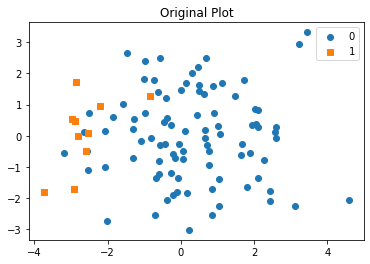

Counter({0: 87, 1: 87})
Resampled Plot: SMOTE + Tomek links


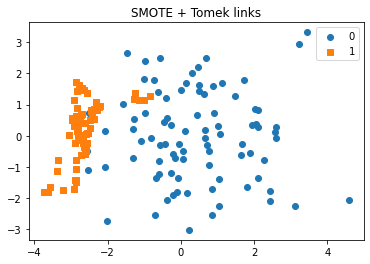

In [134]:
from imblearn.combine import SMOTETomek
from collections import Counter

print(Counter(y))

smt = SMOTETomek(sampling_strategy = 'minority')
X_smt, y_smt = smt.fit_resample(X, y)

print("Original Plot")
plot_2d_space(X, y, 'Original Plot')

print(Counter(y_smt))
print("Resampled Plot: SMOTE + Tomek links")
plot_2d_space(X_smt, y_smt, 'SMOTE + Tomek links')


##  9. Near Miss Undersampling: 

- Near Miss refers to a collection of undersampling methods that select examples based on the distance of majority class examples to minority class examples.
- It has 3 version: Each are different based on the distance calculation considered

    - NearMiss-1: Majority class examples with minimum average distance to **three closest minority** class examples.
    - NearMiss-2: Majority class examples with minimum average distance to **three furthest minority** class examples.
    - NearMiss-3: Majority class examples with minimum distance to **each minority** class example.
 
- Here, distance is determined in feature space using Euclidean distance or similar.

- The NearMiss-3 seems desirable, given that it will only keep those majority class examples that are on the decision boundary.
- Default is NearMiss-1

Counter({0: 90, 1: 10})
Original Plot


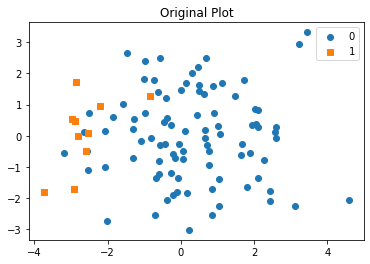

Counter({0: 10, 1: 10})
Resampled Plot: NearMiss under-sampling Version-1


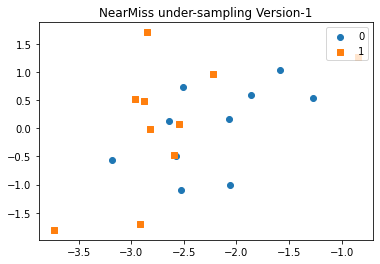

In [135]:
from imblearn.under_sampling  import NearMiss
from collections import Counter

print(Counter(y))

# define the undersampling method version=1
nmu1 = NearMiss(version=1, n_neighbors=3)
X_nmu1, y_nmu1 = nmu1.fit_resample(X, y)


print("Original Plot")
plot_2d_space(X, y, 'Original Plot')

print(Counter(y_nmu1))
print("Resampled Plot: NearMiss under-sampling Version-1")
plot_2d_space(X_nmu1, y_nmu1, 'NearMiss under-sampling Version-1')


#### NearMiss-2: Next, we can demonstrate the NearMiss-2 strategy, which is an inverse to NearMiss-1. It selects examples that are closest to the most distant examples from the minority class, defined by the n_neighbors argument.

Counter({0: 90, 1: 10})
Original Plot


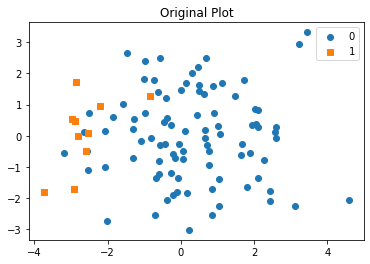

Counter({0: 10, 1: 10})
Resampled Plot: NearMiss under-sampling Version-2


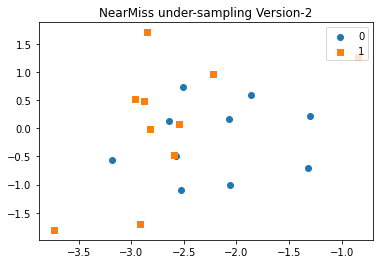

In [136]:
print(Counter(y))
# define the undersampling method version=2
nmu2 = NearMiss(version=2, n_neighbors=3)
X_nmu2, y_nmu2 = nmu2.fit_resample(X, y)


print("Original Plot")
plot_2d_space(X, y, 'Original Plot')

print(Counter(y_nmu2))
print("Resampled Plot: NearMiss under-sampling Version-2")
plot_2d_space(X_nmu2, y_nmu2, 'NearMiss under-sampling Version-2')


### NearMiss- 3 we can try NearMiss-3 that selects the closest examples from the majority class for each minority class.

Counter({0: 90, 1: 10})
Original Plot


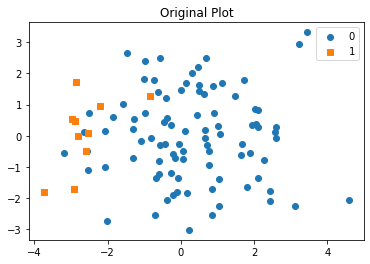

Counter({0: 10, 1: 10})
Resampled Plot: NearMiss under-sampling Version-3


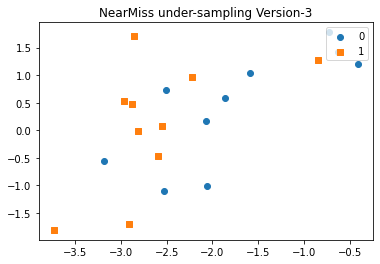

In [137]:
print(Counter(y))
# define the undersampling method version=3
nmu3 = NearMiss(version=3, n_neighbors_ver3=3)
X_nmu3, y_nmu3 = nmu3.fit_resample(X, y)


print("Original Plot")
plot_2d_space(X, y, 'Original Plot')

print(Counter(y_nmu3))
print("Resampled Plot: NearMiss under-sampling Version-3")
plot_2d_space(X_nmu3, y_nmu3, 'NearMiss under-sampling Version-3')


##  10. Condensed Nearest Neighbor(CNN) Rule Undersampling: 

- Condensed Nearest Neighbors, or CNN for short, is an undersampling technique that seeks a subset of a collection of samples that results in no loss in model performance, referred to as a minimal consistent set.

Counter({0: 90, 1: 10})
Original Plot


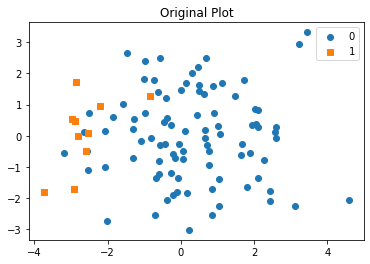

Counter({0: 12, 1: 10})
Resampled Plot: Condensed Nearest Neighbor - Under-sampling


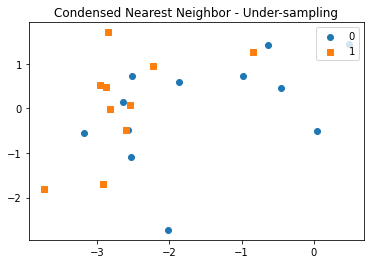

In [138]:
from imblearn.under_sampling import CondensedNearestNeighbour
from collections import Counter

print(Counter(y))
# define the undersampling method
cnn = CondensedNearestNeighbour(n_neighbors=1)
X_cnn, y_cnn = cnn.fit_resample(X, y)


print("Original Plot")
plot_2d_space(X, y, 'Original Plot')

print(Counter(y_cnn))
print("Resampled Plot: Condensed Nearest Neighbor - Under-sampling")
plot_2d_space(X_cnn, y_cnn, 'Condensed Nearest Neighbor - Under-sampling')


##  11. Edited Nearest Neighbors Rule for Undersampling
- Another rule for finding ambiguous and noisy examples in a dataset is called Edited Nearest Neighbors, or sometimes ENN for short.
- This rule involves using k=3 nearest neighbors to locate those examples in a dataset that are misclassified and that are then removed before a k=1 classification rule is applied
- When used as an undersampling procedure, the rule can be applied to each example in the majority class, allowing those examples that are misclassified as belonging to the minority class to be removed, and those correctly classified to remain.
- It is also applied to each example in the minority class where those examples that are misclassified have their nearest neighbors from the majority class deleted.

Counter({0: 90, 1: 10})
Original Plot


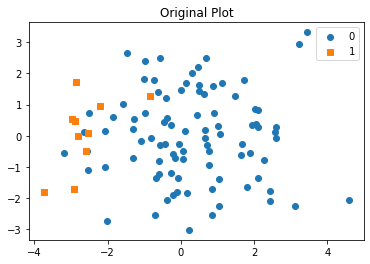

Counter({0: 12, 1: 10})
Resampled Plot:Edited Nearest Neighbors Rule - Under-sampling


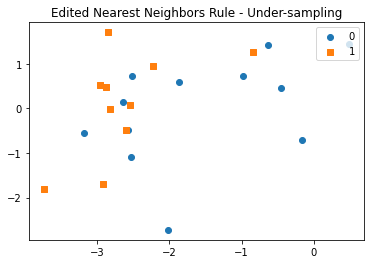

In [139]:
from imblearn.under_sampling import EditedNearestNeighbours
from collections import Counter

print(Counter(y))

X_enn, y_enn = cnn.fit_resample(X, y)


print("Original Plot")
plot_2d_space(X, y, 'Original Plot')

print(Counter(y_enn))
print("Resampled Plot:Edited Nearest Neighbors Rule - Under-sampling")
plot_2d_space(X_enn, y_enn, 'Edited Nearest Neighbors Rule - Under-sampling')
